# Module 1.3 — Calculus & Differential Equations for Quant Finance
## Sensitivity, Approximation, and the Mathematics of Pricing

---

> *"Markets are dynamical systems. Calculus is the mathematics of change — and in finance, change is everything."*

Prices move in time. Risk accumulates through exposure. Small changes in volatility, rates, or underlying price can dominate outcomes. Calculus gives you the tools to **measure, approximate, and model** all of this precisely.

In quant finance, calculus appears in two places that matter most to practitioners:

| Domain | What calculus gives you |
|--------|------------------------|
| **Risk management** | How your PnL responds to small moves — Greeks, duration, convexity |
| **Pricing** | How fair values must evolve under no-arbitrage — the Black–Scholes PDE and its relatives |

---

### What You Will Build in This Notebook

1. **Derivatives & Partial Derivatives** — Define sensitivity rigorously; introduce the Greeks
2. **Taylor Series & Approximations** — PnL decomposition into direction + curvature
3. **Stochastic Calculus & Itô's Lemma** — The chain rule for random processes; why gamma matters
4. **ODEs & PDEs** — Pricing as solving a "law of no-arbitrage" across time and states

**Practical Implementations:**
- Option Greeks: Delta, Gamma, Vega, Theta, Rho (closed-form + numerical verification)
- Black–Scholes PDE solved numerically using finite differences
- Discrete calculus applied to price time series (momentum, regime signals)
- Bond duration and convexity: the fixed-income analogs of Delta and Gamma

---

> *"A practical quant learns to translate each market story into a sensitivity statement, and each sensitivity into a derivative. That is how you become robust: less narrative, more structure."*


In [ ]:
# Let's import the necessary libraries and set a random seed for reproducibility.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log, sqrt, exp
from scipy.stats import norm

np.random.seed(7)

def plot_line(y, title, xlabel="index", ylabel="value"):
    plt.figure(figsize=(9,4))
    plt.plot(y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

---

## 1. Derivatives and Partial Derivatives

### The Core Insight

A derivative is the most disciplined definition of **sensitivity**: how much does output change when input moves by an infinitesimal amount?

In finance, this is the language of risk. Every Greek is a partial derivative. Every hedge is an attempt to cancel one of them.

> *"Risk is local."* A strategy can look safe globally, but locally it may be extremely sensitive to a hidden variable. Derivatives make that sensitivity precise and computable.

---

### The Derivative — Formal Definition

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

This measures the **local rate of change** of $f$ at the point $x$. Geometrically, it is the slope of the tangent line to the curve $f$ at $x$.

**Numerical approximation (central difference):**

$$f'(x) \approx \frac{f(x+h) - f(x-h)}{2h} \quad \text{for small } h$$

$$f''(x) \approx \frac{f(x+h) - 2f(x) + f(x-h)}{h^2}$$

The central difference is more accurate than the one-sided difference because it cancels the first-order error term.

---

### Partial Derivatives — Sensitivity Along One Dimension

An option price depends on multiple variables simultaneously:

$$V = V(S,\; t,\; \sigma,\; r)$$

A **partial derivative** measures sensitivity to one variable while holding all others fixed:

$$\frac{\partial V}{\partial S} \bigg|_{t, \sigma, r \; \text{fixed}}$$

This is a geometric idea: each variable is a **risk axis**, and the partial derivative gives the slope along that axis.

---

### The Option Greeks — Partial Derivatives in Practice

Each Greek answers the question: *"If this one thing changes by a small amount, how much does my option value change?"*

| Greek | Symbol | Partial Derivative | What It Measures |
|-------|--------|--------------------|-----------------|
| Delta | $\Delta$ | $\partial V / \partial S$ | Sensitivity to underlying price — directional exposure |
| Gamma | $\Gamma$ | $\partial^2 V / \partial S^2$ | Rate of change of Delta — curvature / convexity |
| Vega | $\nu$ | $\partial V / \partial \sigma$ | Sensitivity to volatility — key in regime changes |
| Theta | $\Theta$ | $\partial V / \partial t$ | Sensitivity to time — time decay (always negative for long options) |
| Rho | $\rho$ | $\partial V / \partial r$ | Sensitivity to interest rate |

**Key market intuition:**

- **Delta-hedging** cancels the first-order ($\Delta$) exposure — you are flat to small moves in $S$
- But **Gamma** remains — the second-order term survives and dominates in large or volatile moves
- **Vega** is often the most dangerous Greek in practice: implied volatility can spike suddenly, overwhelming direction bets
- **Theta** is the cost of owning optionality — long options lose value every day, all else equal

> Partial derivatives force honesty: they tell you exactly what you are betting on — direction, curvature, volatility, time, or rates — even when your narrative says otherwise.


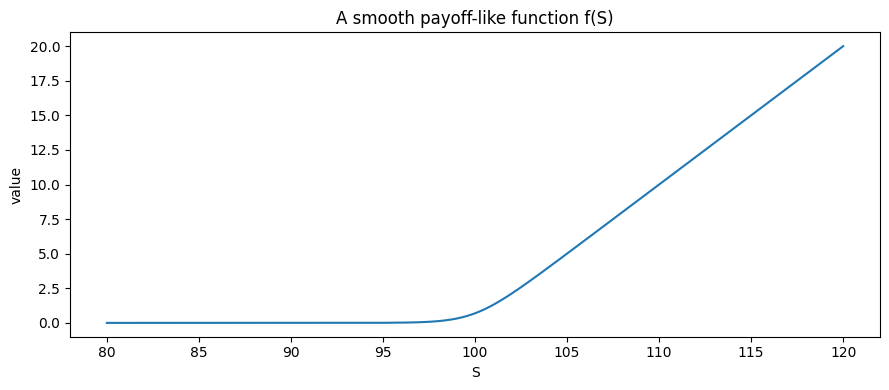

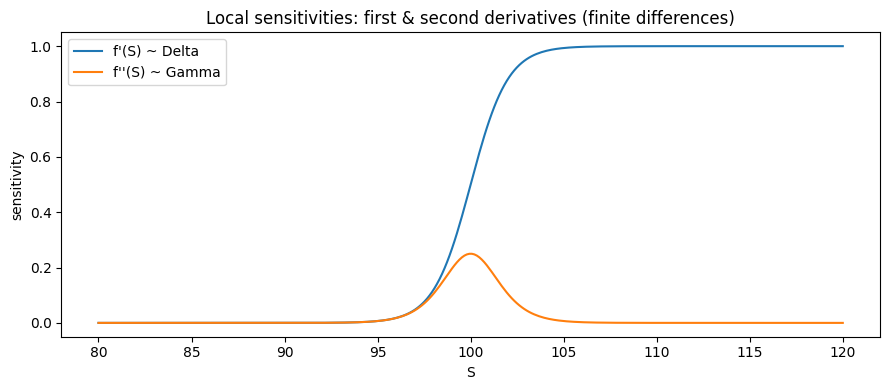

(np.float64(0.5000000001531557), np.float64(0.2500000095828625))

In [ ]:
# Numerical derivatives (finite differences) and intution
def finite_diff_first(f, x, h=1e-5):
    return (f(x+h) - f(x-h)) / (2*h)

def finite_diff_second(f, x, h=1e-4):
    return (f(x+h) - 2*f(x) + f(x-h)) / (h*h)

# Example: nonlinear payoff-like function
def f_price(S):
    # a smooth "payoff-ish" curve: saturating growth with curvature
    return np.log(1 + np.exp(S - 100))

S0 = 100.0
delta_num = finite_diff_first(f_price, S0)
gamma_num = finite_diff_second(f_price, S0)

S_grid = np.linspace(80, 120, 300)
vals = [f_price(s) for s in S_grid]
d1  = [finite_diff_first(f_price, s) for s in S_grid]
d2  = [finite_diff_second(f_price, s) for s in S_grid]

plt.figure(figsize=(9,4))
plt.plot(S_grid, vals, label="f(S)")
plt.title("A smooth payoff-like function f(S)")
plt.xlabel("S")
plt.ylabel("value")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.plot(S_grid, d1, label="f'(S) ~ Delta")
plt.plot(S_grid, d2, label="f''(S) ~ Gamma")
plt.title("Local sensitivities: first & second derivatives (finite differences)")
plt.xlabel("S")
plt.ylabel("sensitivity")
plt.legend()
plt.tight_layout()
plt.show()

delta_num, gamma_num

---

## 2. Taylor Series and Approximations

### The Core Insight

Taylor series is the quantitative answer to the question: *"If I know a function's value and derivatives at one point, how well can I predict it nearby?"*

> **Taylor's insight:** Any smooth function can be approximated locally by a polynomial. The more terms you include, the wider the neighborhood where the approximation holds.

In finance, the second-order Taylor approximation is the foundation of **PnL decomposition** — how traders decompose risk into direction and curvature.

---

### The Taylor Expansion

Around a point $x_0$, a smooth function $f$ can be approximated as:

$$f(x_0 + \Delta x) \approx f(x_0) + f'(x_0)\,\Delta x + \frac{1}{2}f''(x_0)\,(\Delta x)^2 + \underbrace{\cdots}_{\text{higher order}}$$

| Term | Name | Captures |
|------|------|---------|
| $f(x_0)$ | Zeroth order | Current value |
| $f'(x_0)\,\Delta x$ | First order (linear) | Direction — how $f$ moves for small $\Delta x$ |
| $\frac{1}{2}f''(x_0)\,(\Delta x)^2$ | Second order (quadratic) | Curvature — how the rate of change itself changes |

---

### PnL Decomposition: The Finance Version

For an option with value $V(S)$, a move $\Delta S$ in the underlying produces:

$$\Delta V \approx \underbrace{\Delta \cdot \Delta S}_{\text{Delta PnL}} + \underbrace{\frac{1}{2}\,\Gamma\,(\Delta S)^2}_{\text{Gamma PnL}}$$

where $\Delta = \partial V / \partial S$ and $\Gamma = \partial^2 V / \partial S^2$.

**What this means in practice:**

| Market Condition | Dominant Term | Implication |
|-----------------|--------------|-------------|
| Small moves, low vol | $\Delta \cdot \Delta S$ | Delta hedge is sufficient |
| Large moves, high vol | $\frac{1}{2}\Gamma(\Delta S)^2$ | Gamma dominates; delta hedge insufficient |
| Delta-hedged book | $\frac{1}{2}\Gamma(\Delta S)^2$ only | Net PnL comes entirely from curvature |

---

### Why Delta-Hedging Is Never Perfect

Delta-hedging cancels the **first-order term** locally. But the second-order (Gamma) term always remains. This means:

- In **calm markets**: Gamma PnL is small — delta hedging works well
- In **volatile markets**: Gamma PnL dominates — a delta-hedged long option position profits from large moves; a delta-hedged short option position loses

This is the mathematical explanation for the market saying: *"Long gamma loves volatility; short gamma fears it."*

> **Philosophical insight:** Taylor series teaches why hedging is never perfect — and why you must always ask not just "what is my slope?" but "what is my curvature?"


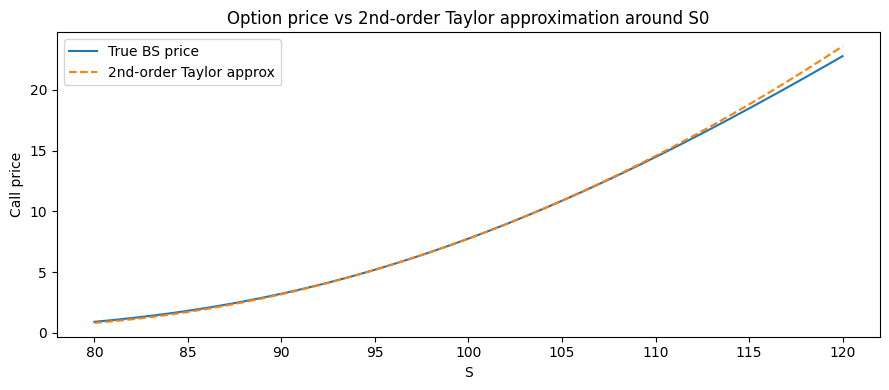

(np.float64(7.760256671909239),
 np.float64(0.5687690646779758),
 np.float64(0.02223145685106345))

In [ ]:
# Taylor PnL approximation vs true value (using a call option)
def bs_call_price(S, K, T, r, sigma):
    if T <= 0:
        return max(S - K, 0.0)
    d1 = (log(S/K) + (r + 0.5*sigma*sigma)*T) / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)
    return S*norm.cdf(d1) - K*exp(-r*T)*norm.cdf(d2)

def bs_call_delta(S, K, T, r, sigma):
    if T <= 0:
        return 1.0 if S > K else 0.0
    d1 = (log(S/K) + (r + 0.5*sigma*sigma)*T) / (sigma*sqrt(T))
    return norm.cdf(d1)

def bs_call_gamma(S, K, T, r, sigma):
    if T <= 0:
        return 0.0
    d1 = (log(S/K) + (r + 0.5*sigma*sigma)*T) / (sigma*sqrt(T))
    return norm.pdf(d1) / (S*sigma*sqrt(T))

S0, K, T, r, sigma = 100, 100, 0.5, 0.03, 0.25
V0 = bs_call_price(S0, K, T, r, sigma)
Delta0 = bs_call_delta(S0, K, T, r, sigma)
Gamma0 = bs_call_gamma(S0, K, T, r, sigma)

dS = np.linspace(-20, 20, 200)
V_true = np.array([bs_call_price(S0+ds, K, T, r, sigma) for ds in dS])
V_taylor2 = V0 + Delta0*dS + 0.5*Gamma0*(dS**2)

plt.figure(figsize=(9,4))
plt.plot(S0+dS, V_true, label="True BS price")
plt.plot(S0+dS, V_taylor2, "--", label="2nd-order Taylor approx")
plt.title("Option price vs 2nd-order Taylor approximation around S0")
plt.xlabel("S")
plt.ylabel("Call price")
plt.legend()
plt.tight_layout()
plt.show()

V0, Delta0, Gamma0

---

## 3. Stochastic Calculus and Itô's Lemma

### The Core Insight

Classical calculus assumes smooth, differentiable paths. Market prices are not smooth — they are jagged, noisy, and their randomness does **not** vanish as the time step shrinks. A fundamentally different calculus is needed.

> **The key difference:** In ordinary calculus, $(dx)^2 \to 0$ as $dx \to 0$. In stochastic calculus, $(dW_t)^2 \approx dt$ — second-order random terms survive and cannot be ignored.

This single fact changes everything: it is the origin of the Gamma term in PnL, the diffusion term in the Black–Scholes PDE, and the reason options have time value.

---

### Geometric Brownian Motion (GBM)

The standard model for stock prices:

$$dS_t = \underbrace{\mu S_t \, dt}_{\text{drift}} + \underbrace{\sigma S_t \, dW_t}_{\text{diffusion}}$$

| Symbol | Meaning |
|--------|---------|
| $\mu$ | Drift — expected instantaneous return rate (annualized) |
| $\sigma$ | Diffusion coefficient — instantaneous volatility (annualized) |
| $W_t$ | Standard Brownian motion: $W_0 = 0$, increments $dW_t \sim \mathcal{N}(0, dt)$ |
| $S_t$ | Asset price at time $t$ |

**Key property of Brownian motion:**

$$dW_t \sim \mathcal{N}(0, dt), \qquad (dW_t)^2 \approx dt$$

The second equality is not an approximation in the ordinary sense — it holds almost surely in the limit, and it is what makes stochastic calculus different from classical calculus.

**Exact discretization for simulation:**

$$S_{t+\Delta t} = S_t \cdot \exp\!\left(\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t}\, Z_t\right), \quad Z_t \sim \mathcal{N}(0,1)$$

The $-\sigma^2/2$ term is **Itô's correction** — it appears because of the $(dW)^2 \approx dt$ rule and ensures the expected log-return is consistent with the drift.

---

### Itô's Lemma — The Chain Rule for Stochastic Processes

If $S_t$ follows $dS_t = a(S,t)\,dt + b(S,t)\,dW_t$ and $V = V(S,t)$ is a smooth function, then:

$$dV = \underbrace{\left(\frac{\partial V}{\partial t} + a\frac{\partial V}{\partial S} + \frac{1}{2}b^2\frac{\partial^2 V}{\partial S^2}\right)}_{\text{drift of } V}\,dt \;+\; \underbrace{b\frac{\partial V}{\partial S}}_{\text{diffusion of } V}\,dW_t$$

The **extra term** $\frac{1}{2}b^2 \frac{\partial^2 V}{\partial S^2}$ has no analog in classical calculus. It arises precisely because $(dW_t)^2 \approx dt$.

**For GBM** ($a = \mu S$, $b = \sigma S$):

$$dV = \left(\frac{\partial V}{\partial t} + \mu S\frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2\frac{\partial^2 V}{\partial S^2}\right)dt + \sigma S\frac{\partial V}{\partial S}\,dW_t$$

---

### The Three Terms and Their Finance Meaning

| Term | Symbol | Finance Meaning |
|------|--------|----------------|
| $\frac{\partial V}{\partial t}$ | Theta | Time decay — how $V$ erodes as time passes |
| $\mu S \frac{\partial V}{\partial S}$ | Delta $\times$ drift | First-order exposure to the expected price move |
| $\frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}$ | $\frac{1}{2}\sigma^2 S^2 \Gamma$ | **The Itô correction** — curvature gain from randomness |

The Itô correction is why **Gamma** matters even in a delta-hedged book. After canceling Delta, a delta-neutral portfolio still earns (or loses) $\frac{1}{2}\sigma^2 S^2 \Gamma \, dt$ per unit time from the randomness itself. This is the mathematical engine of option pricing.

---

### Why Log-Returns Are Normally Distributed

Applying Itô's Lemma to $\log S_t$:

$$d(\log S_t) = \left(\mu - \frac{\sigma^2}{2}\right)dt + \sigma\,dW_t$$

So log-returns over any interval $[t, t+\Delta t]$ are:

$$\log\frac{S_{t+\Delta t}}{S_t} \sim \mathcal{N}\!\left(\left(\mu - \frac{\sigma^2}{2}\right)\Delta t,\; \sigma^2 \Delta t\right)$$

The $-\sigma^2/2$ is the **volatility drag** — the gap between arithmetic and geometric returns. A portfolio with 20% volatility and 10% expected return actually grows at roughly $10\% - \frac{(0.20)^2}{2} = 8\%$ per year in geometric terms.

> **Philosophical insight:** When the world is noisy, curvature becomes destiny. Itô's Lemma is the proof.


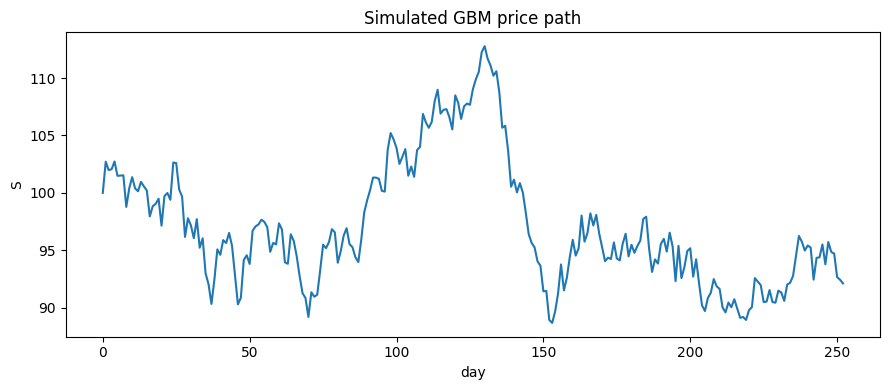

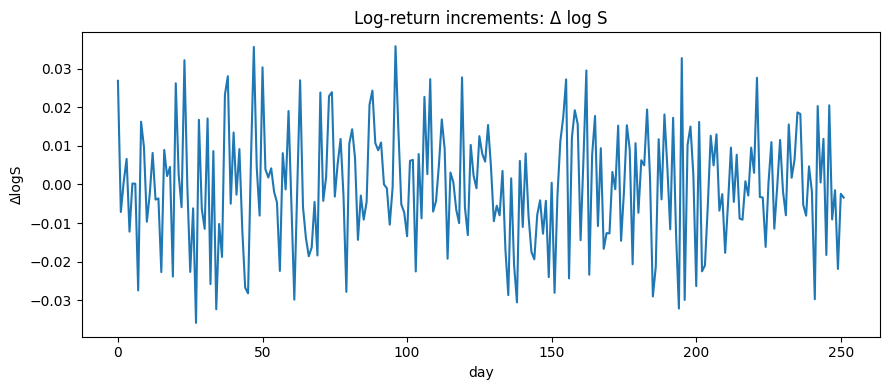

Empirical mean ΔlogS: -0.0003255133628820634 Theory: 0.00019345238095238096
Empirical var  ΔlogS: 0.0002275076513538342 Theory: 0.000248015873015873


In [ ]:
# Simulate geometric Brownian motion (GBM) and compare log-returns to theory
S0 = 100
mu = 0.08
sigma = 0.25
T = 1.0
N = 252
dt = T/N

# GBM exact discretization
Z = np.random.randn(N)
S = np.empty(N+1)
S[0] = S0
for t in range(N):
    S[t+1] = S[t] * np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[t])

logS = np.log(S)

plot_line(S, "Simulated GBM price path", xlabel="day", ylabel="S")
plot_line(np.diff(logS), "Log-return increments: Δ log S", xlabel="day", ylabel="ΔlogS")

# For GBM: ΔlogS ~ Normal((mu - 0.5 sigma^2)dt, sigma^2 dt)
dlogS = np.diff(logS)
print("Empirical mean ΔlogS:", dlogS.mean(), "Theory:", (mu - 0.5*sigma**2)*dt)
print("Empirical var  ΔlogS:", dlogS.var(ddof=1), "Theory:", (sigma**2)*dt)

---

## 4. Ordinary and Partial Differential Equations (ODEs & PDEs)

### The Core Insight

A differential equation is a **law of change** — it does not describe a single value, but a rule that all values must obey. In finance, no-arbitrage arguments impose exactly such laws on option prices.

> A PDE is a contract between states of the world: you cannot assign prices independently at each $S$ and $t$. No-arbitrage links them through a differential law.

---

### ODEs vs PDEs

**Ordinary Differential Equation (ODE)** — one variable evolves in time:

$$\frac{dx}{dt} = f(x, t)$$

Example in finance: portfolio growth under continuous compounding, $\frac{dW}{dt} = rW$, which gives $W(t) = W_0 e^{rt}$.

**Partial Differential Equation (PDE)** — a function of multiple variables must satisfy a relationship involving its partial derivatives:

$$\frac{\partial u}{\partial t} = \mathcal{L}\,u$$

where $\mathcal{L}$ is a differential operator acting on the spatial variables. Finance produces PDEs because prices depend on both time $t$ and state $S$.

---

### The Black–Scholes PDE

Under the assumptions of GBM, frictionless trading, and continuous delta-hedging, the option price $V(S, t)$ must satisfy:

$$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + rS\frac{\partial V}{\partial S} - rV = 0$$

with **terminal condition** (at expiry $T$):

$$V(S, T) = \max(S - K,\; 0) \quad \text{(European call)}$$

**Breaking down each term:**

| Term | Greek | Economic Meaning |
|------|-------|-----------------|
| $\frac{\partial V}{\partial t}$ | $\Theta$ | Time decay — option loses value as expiry approaches |
| $\frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}$ | $\frac{1}{2}\sigma^2 S^2 \Gamma$ | Diffusion — curvature gain from random price moves |
| $rS \frac{\partial V}{\partial S}$ | $r S \Delta$ | Drift under risk-neutral measure — expected return equals risk-free rate |
| $-rV$ | — | Discounting — the option's value grows at the risk-free rate |

The PDE says: **time decay + diffusion gain + drift exposure = discounting cost**. These must balance exactly, or there would be arbitrage.

---

### Boundary Conditions

The PDE alone is not enough — you also need boundary conditions to pin down the solution:

| Condition | Formula | Economic Meaning |
|-----------|---------|-----------------|
| At $S = 0$ | $V(0, t) = 0$ | A worthless stock leaves the call worthless |
| At $S \to \infty$ | $V(S, t) \approx S - Ke^{-r(T-t)}$ | Deep in-the-money option ≈ forward contract |
| At $t = T$ | $V(S, T) = \max(S-K, 0)$ | Option expires at intrinsic value |

---

### Why PDE Methods Matter in Practice

The Black–Scholes formula is a closed-form solution to the BS PDE only under special assumptions (constant $\sigma$, European exercise, no barriers). For almost everything else, you must solve the PDE **numerically**:

| Product / Feature | Closed form? | Need PDE? |
|------------------|-------------|----------|
| European call/put | Yes (BS formula) | Optional |
| American option (early exercise) | No | Yes |
| Barrier option (knock-in/out) | Partial | Yes |
| Local volatility model | No | Yes |
| Path-dependent exotics | No | Yes (or Monte Carlo) |

> **Philosophical insight:** PDEs turn the no-arbitrage principle into a computable algorithm. Even when the formula is unavailable, the law remains — and numerical methods turn that law into a price.


---

## Practice 1 — Option Greeks: Delta, Gamma, Vega, Theta, Rho

### What Are Greeks?

Greeks are the **partial derivatives of the option price** with respect to each market variable. They are the primary language risk managers and traders use to describe, aggregate, and hedge option exposures.

$$\Delta = \frac{\partial V}{\partial S}, \quad \Gamma = \frac{\partial^2 V}{\partial S^2}, \quad \nu = \frac{\partial V}{\partial \sigma}, \quad \Theta = \frac{\partial V}{\partial t}, \quad \rho = \frac{\partial V}{\partial r}$$

---

### Black–Scholes Closed-Form Greeks

For a European call with spot $S$, strike $K$, time to expiry $T$, risk-free rate $r$, and volatility $\sigma$:

$$d_1 = \frac{\ln(S/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

| Greek | Formula | Typical sign for long call | What happens as it changes |
|-------|---------|--------------------------|---------------------------|
| Price | $S\,\Phi(d_1) - Ke^{-rT}\Phi(d_2)$ | Positive | — |
| $\Delta$ | $\Phi(d_1)$ | $\in (0, 1)$ | Increases as $S$ rises (ATM $\approx$ 0.5) |
| $\Gamma$ | $\phi(d_1) / (S\sigma\sqrt{T})$ | Positive | Peaks at-the-money; falls as $S$ moves away |
| $\nu$ | $S\,\phi(d_1)\sqrt{T}$ | Positive | Larger for longer-dated options |
| $\Theta$ | $-\frac{S\phi(d_1)\sigma}{2\sqrt{T}} - rKe^{-rT}\Phi(d_2)$ | Negative | Accelerates as expiry nears |
| $\rho$ | $KTe^{-rT}\Phi(d_2)$ | Positive | Larger for longer-dated, deeper ITM options |

where $\Phi(\cdot)$ is the standard normal CDF and $\phi(\cdot)$ is the standard normal PDF.

---

### Numerical Verification

All Greeks can also be computed by **finite differences** — perturbing each input slightly and measuring the change in option price. This serves two purposes:

1. **Validation**: The closed-form and numerical results should match closely
2. **Generalization**: When no closed form exists (American options, exotic products), finite differences still work

> **Note on Theta sign convention:** $\Theta = \partial V / \partial t$ measures sensitivity to calendar time (decreasing $T$), so it is **negative** for long options. The finite-difference check computes $\partial V / \partial T$ (increasing time-to-maturity), which has the **opposite sign** — this is expected and not an error.

---

### Practical Trading Intuitions

**Being right on direction is not enough.** Consider a trader who correctly predicts the stock will rise, but:
- Implied volatility collapses after they buy calls → Vega loss wipes out Delta gain
- The move takes too long → Theta decay erodes value day by day
- The move is small → Gamma is irrelevant, but they overpaid for optionality

Greeks make these scenarios explicit and quantifiable.

| Scenario | Dominant Greek | Risk |
|----------|---------------|------|
| Stock moves a lot | $\Gamma$ | Short gamma position loses on large moves |
| Volatility spikes | $\nu$ | Short vega position loses when vol rises |
| Time passes quietly | $\Theta$ | Long options slowly decay to zero |
| Rates move significantly | $\rho$ | Long-dated options sensitive to rate changes |


In [ ]:
def bs_call_greeks(S, K, T, r, sigma):
    if T <= 0:
        price = max(S-K, 0.0)
        return {"price": price, "delta": 1.0 if S>K else 0.0, "gamma": 0.0, "vega": 0.0, "theta": 0.0, "rho": 0.0}

    d1 = (log(S/K) + (r + 0.5*sigma*sigma)*T) / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)

    price = S*norm.cdf(d1) - K*exp(-r*T)*norm.cdf(d2)
    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S*sigma*sqrt(T))
    vega  = S*norm.pdf(d1)*sqrt(T)              # per 1.0 change in sigma
    theta = -(S*norm.pdf(d1)*sigma)/(2*sqrt(T)) - r*K*exp(-r*T)*norm.cdf(d2)
    rho   = K*T*exp(-r*T)*norm.cdf(d2)

    return {"price": price, "delta": delta, "gamma": gamma, "vega": vega, "theta": theta, "rho": rho}

S, K, T, r, sigma = 100, 100, 0.5, 0.03, 0.25
g = bs_call_greeks(S, K, T, r, sigma)
g

{'price': np.float64(7.760256671909239),
 'delta': np.float64(0.5687690646779758),
 'gamma': np.float64(0.02223145685106345),
 'vega': np.float64(27.789321063829313),
 'theta': np.float64(-8.420829759833978),
 'rho': np.float64(24.55832489794417)}

In [ ]:
# Finite-difference checks (numerical partial derivatives)
def price_S(x): return bs_call_price(x, K, T, r, sigma)
def price_sig(x): return bs_call_price(S, K, T, r, x)
def price_r(x): return bs_call_price(S, K, T, x, sigma)
def price_T(x): return bs_call_price(S, K, x, r, sigma)

hS, hs, hr, hT = 1e-3, 1e-4, 1e-5, 1e-5

delta_fd = (price_S(S+hS) - price_S(S-hS)) / (2*hS)
gamma_fd = (price_S(S+hS) - 2*price_S(S) + price_S(S-hS)) / (hS*hS)
vega_fd  = (price_sig(sigma+hs) - price_sig(sigma-hs)) / (2*hs)
rho_fd   = (price_r(r+hr) - price_r(r-hr)) / (2*hr)
theta_fd = (price_T(T+hT) - price_T(T-hT)) / (2*hT)   # derivative w.r.t. T (time-to-maturity)

pd.DataFrame({
    "closed_form": [g["delta"], g["gamma"], g["vega"], g["rho"], g["theta"]],
    "finite_diff": [delta_fd, gamma_fd, vega_fd, rho_fd, theta_fd],
}, index=["Delta", "Gamma", "Vega(nu)", "Rho", "Theta (∂/∂T)"])

,closed_form,finite_diff
Delta,0.568769,0.568769
Gamma,0.022231,0.022231
Vega(nu),27.789321,27.789321
Rho,24.558325,24.558325
Theta (∂/∂T),-8.420830,8.420830


---

## Practice 2 — Numerical Solution of the Black–Scholes PDE (Finite Differences)

### Why Solve Numerically?

The Black–Scholes formula is elegant — but it only works under very specific assumptions. In practice:
- Volatility is not constant (local vol, stochastic vol models)
- Options may have early exercise features (American options)
- Payoffs may be path-dependent (barriers, lookbacks)

In all these cases, **no closed form exists** and you must solve the PDE numerically. The explicit finite-difference method is the simplest approach and builds the right intuition.

---

### The Discretization Scheme

We discretize the $(S, t)$ domain into a grid:
- $S$-axis: $S_0 = 0, S_1, \dots, S_M = S_{\max}$ with spacing $\Delta S = S_{\max}/M$
- $t$-axis: $t_0 = 0, t_1, \dots, t_N = T$ with spacing $\Delta t = T/N$

We solve **backward in time** from the known terminal payoff at $t = T$ toward $t = 0$.

**Discretized BS PDE (explicit scheme)** at interior grid point $i$, time step $n$:

$$V_i^{n} = a_i\, V_{i-1}^{n+1} + b_i\, V_i^{n+1} + c_i\, V_{i+1}^{n+1}$$

where the coefficients come from the PDE terms:

$$a_i = \frac{\Delta t}{2}\left(\frac{\sigma^2 S_i^2}{\Delta S^2} - \frac{r S_i}{\Delta S}\right), \quad b_i = 1 - \Delta t\left(\frac{\sigma^2 S_i^2}{\Delta S^2} + r\right), \quad c_i = \frac{\Delta t}{2}\left(\frac{\sigma^2 S_i^2}{\Delta S^2} + \frac{r S_i}{\Delta S}\right)$$

---

### Stability Requirement

The explicit scheme is **conditionally stable**: it requires small enough $\Delta t$ relative to $\Delta S$. A rough rule is:

$$\Delta t \lesssim \frac{(\Delta S)^2}{\sigma^2 S_{\max}^2}$$

If you choose $\Delta t$ too large, the scheme produces oscillating, nonsensical prices. This is why we use `N=5000` steps for `M=250` grid points. The implicit (Crank–Nicolson) scheme is unconditionally stable but requires solving a linear system at each step — more complex but more efficient for production use.

---

### What the PDE Solver Teaches

> You directly see how the Black–Scholes formula emerges as the solution to a diffusion-like law. The curvature (Gamma) diffuses value backward through time, boundary conditions impose economic constraints, and the result is a smooth price surface $V(S, t)$.

The absolute errors in the output (typically $< 0.01$) come entirely from grid discretization — they shrink as $M$ and $N$ increase.


In [ ]:
def bs_pde_call_explicit(Smax=300, K=100, T=1.0, r=0.03, sigma=0.25, M=400, N=4000):
    """
    Explicit finite-difference solver for Black–Scholes PDE.
    Returns: S grid, V at t=0.
    Note: explicit schemes require stability constraints; choose N large enough.
    """
    dS = Smax / M
    dt = T / N

    S = np.linspace(0, Smax, M+1)
    V = np.maximum(S - K, 0.0)  # terminal payoff at t=T

    # Precompute coefficients for interior points i=1..M-1
    i = np.arange(1, M)
    Si = S[i]

    a = 0.5*dt*(sigma**2 * (Si**2) / (dS**2) - r*Si/dS)
    b = 1 - dt*(sigma**2 * (Si**2) / (dS**2) + r)
    c = 0.5*dt*(sigma**2 * (Si**2) / (dS**2) + r*Si/dS)

    for n_step in range(N):
        t = T - n_step*dt  # current time (backward)
        V_new = V.copy()

        # Boundary conditions at time t-dt:
        V_new[0] = 0.0
        V_new[M] = Smax - K*np.exp(-r*(t-dt))  # large-S boundary approx

        # Update interior
        V_new[i] = a*V[i-1] + b*V[i] + c*V[i+1]
        V = V_new

    return S, V

Sgrid, V0_grid = bs_pde_call_explicit(Smax=300, K=100, T=0.5, r=0.03, sigma=0.25, M=250, N=5000)

# Compare PDE price to closed form at a few points
test_S = [80, 100, 120, 150]
rows = []
for s in test_S:
    pde_price = np.interp(s, Sgrid, V0_grid)
    bs_price = bs_call_price(s, 100, 0.5, 0.03, 0.25)
    rows.append({"S": s, "PDE": pde_price, "ClosedForm": bs_price, "AbsErr": abs(pde_price - bs_price)})
pd.DataFrame(rows)

,S,PDE,ClosedForm,AbsErr
0,80,0.922603,0.919547,0.003055
1,100,7.763538,7.760257,0.003281
2,120,22.763381,22.762665,0.000716
3,150,51.551396,51.550964,0.000432


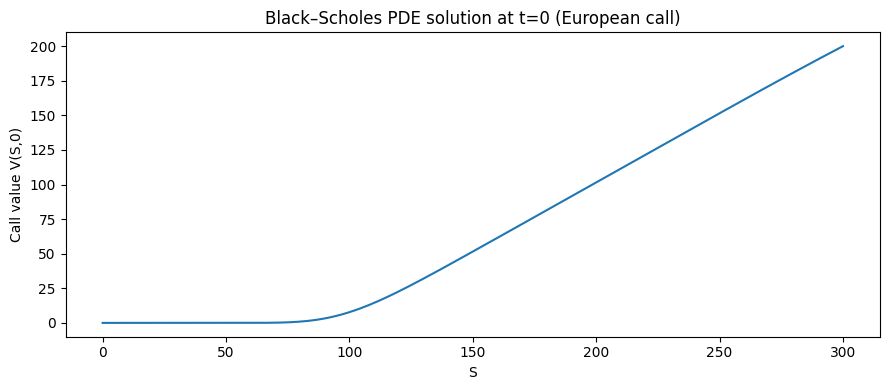

In [ ]:
plt.figure(figsize=(9,4))
plt.plot(Sgrid, V0_grid, label="PDE (t=0)")
plt.title("Black–Scholes PDE solution at t=0 (European call)")
plt.xlabel("S")
plt.ylabel("Call value V(S,0)")
plt.tight_layout()
plt.show()

---

## Practice 3 — Time-Series Analysis with Discrete Derivatives

### The Core Insight

In market data, continuous derivatives are replaced by **discrete analogs**: finite differences computed on sampled price series. These are not mystical indicators — they are simply the digital version of the same calculus ideas.

---

### Discrete Calculus on Price Series

Let $P_t$ be the price at time $t$ and $x_t = \log P_t$ the log-price.

**First difference** (discrete first derivative — log-return):

$$\Delta x_t = x_t - x_{t-1} \approx \frac{P_t - P_{t-1}}{P_{t-1}}$$

This approximates the continuously compounded return. It is the "velocity" of the log-price.

**Second difference** (discrete second derivative — acceleration):

$$\Delta^2 x_t = \Delta x_t - \Delta x_{t-1} = x_t - 2x_{t-1} + x_{t-2}$$

This captures changes in momentum — the "acceleration" of the price. A large positive $\Delta^2 x_t$ means the price is accelerating upward; a large negative means it is decelerating or reversing.

---

### Why Log-Price Instead of Price?

| Property | $P_t$ (price) | $x_t = \log P_t$ (log-price) |
|----------|--------------|---------------------------|
| Additivity | $P_t - P_0$ (dollar PnL) | $x_t - x_0$ (compounded return) |
| Stationarity | Non-stationary (trends) | First differences are approximately stationary |
| Symmetry | A 50% loss requires a 100% gain to recover | $\log$ differences are symmetric |
| Model consistency | GBM implies log-normal $P_t$ | GBM implies normal $\Delta x_t$ |

---

### From Raw Differences to Trading Signals

Raw finite differences are **noisy** — they react to every tick. Professional practice applies smoothing before differencing:

**Exponential Moving Average (EMA) then difference:**

$$\tilde{x}_t = \alpha x_t + (1-\alpha)\tilde{x}_{t-1}, \qquad \alpha \in (0,1)$$

$$\Delta \tilde{x}_t = \tilde{x}_t - \tilde{x}_{t-1}$$

Small $\alpha$ (e.g., 0.05) gives heavy smoothing — slow to react but stable. Large $\alpha$ (e.g., 0.3) gives light smoothing — fast but noisy.

**Common trading signal patterns:**

| Signal pattern | Meaning | Strategy implication |
|---------------|---------|---------------------|
| $\Delta x_t > 0$ persistently | Trend — upward momentum | Momentum long |
| $\Delta x_t$ changes sign | Reversal | Mean-reversion signal |
| $\Delta^2 x_t$ large negative | Deceleration of uptrend | Potential exit from momentum long |
| $\Delta^2 x_t$ large positive after downtrend | Downtrend losing steam | Potential mean-reversion entry |

---

### The Connection to Calculus

Discrete differences are approximations of continuous derivatives as the time step $\Delta t \to 0$:

$$\Delta x_t \approx \frac{dx}{dt} \cdot \Delta t, \qquad \Delta^2 x_t \approx \frac{d^2x}{dt^2} \cdot (\Delta t)^2$$

In practice, you cannot take $\Delta t \to 0$ — you are limited by the sampling frequency of your data. This is why smoothing matters: it approximates the continuous derivative by averaging out the measurement noise inherent in finite sampling.


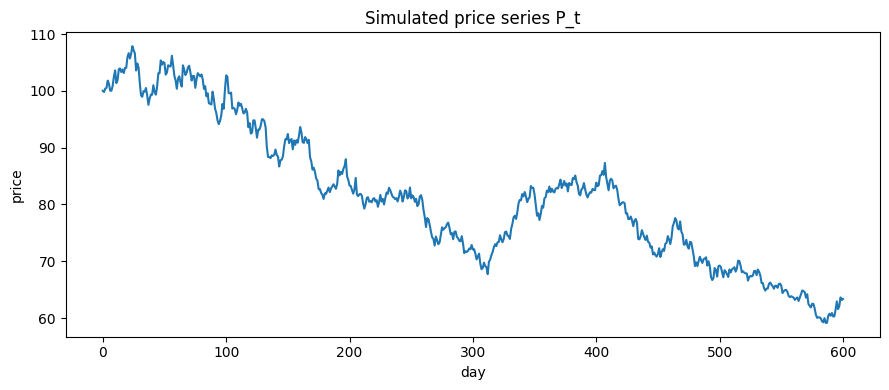

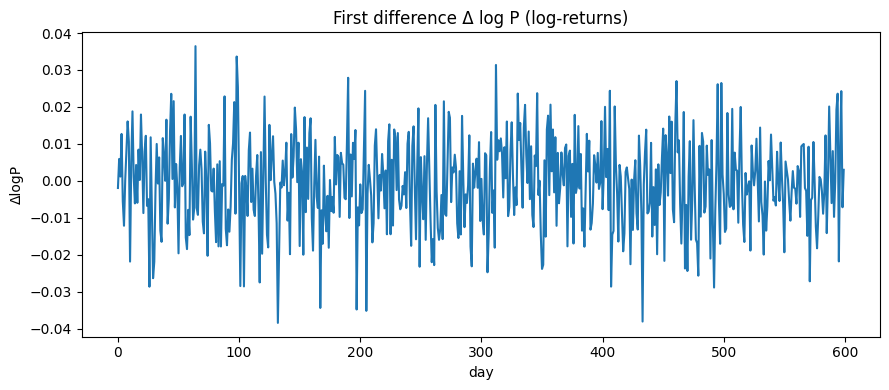

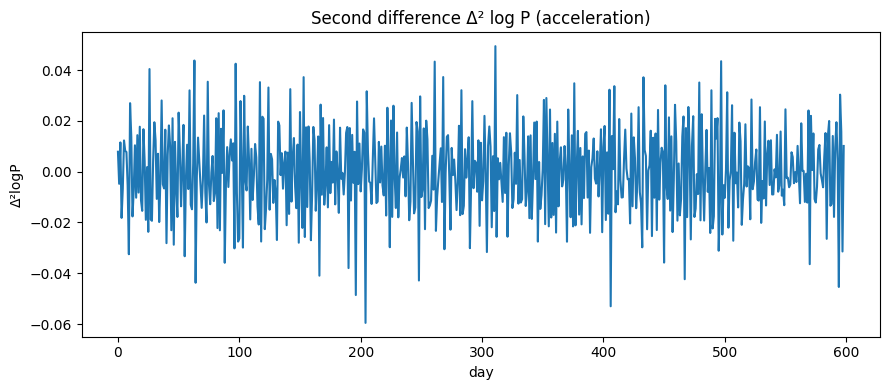

In [ ]:
# Simulate a price series with regimes: trend then mean-reversion-ish noise
T = 600
dt = 1/252
trend1 = 0.12
trend2 = -0.05
sigma = 0.20

Z = np.random.randn(T)
drift = np.r_[np.full(T//2, trend1), np.full(T - T//2, trend2)]
logP = np.zeros(T+1)
logP[0] = np.log(100.0)

for t in range(T):
    logP[t+1] = logP[t] + (drift[t] - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[t]

P = np.exp(logP)
x = np.log(P)

dx = np.diff(x)           # first difference ~ log returns
d2x = np.diff(dx)         # second difference

plot_line(P, "Simulated price series P_t", xlabel="day", ylabel="price")
plot_line(dx, "First difference Δ log P (log-returns)", xlabel="day", ylabel="ΔlogP")
plot_line(d2x, "Second difference Δ² log P (acceleration)", xlabel="day", ylabel="Δ²logP")

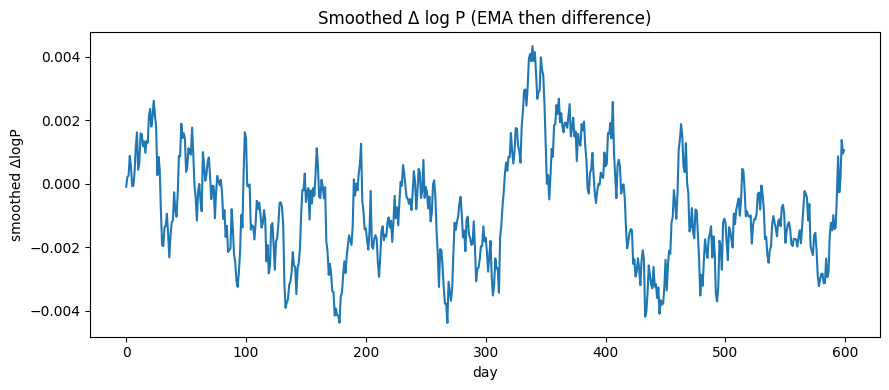

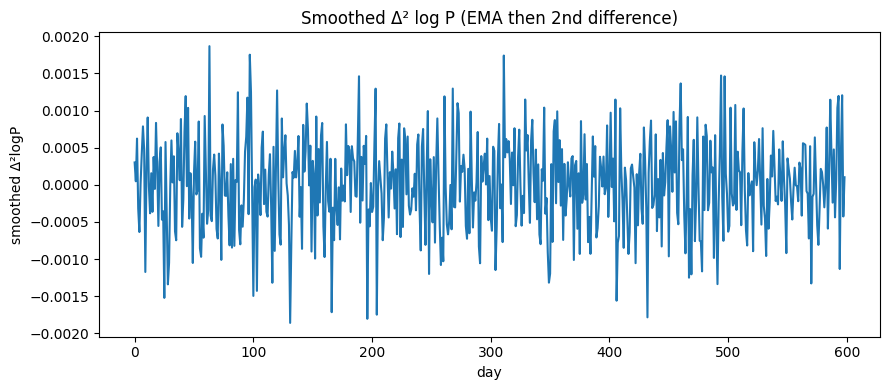

In [ ]:
# Simple smoothing then derivative (more realistic)
def ema(y, alpha=0.1):
    y = np.asarray(y)
    out = np.empty_like(y)
    out[0] = y[0]
    for i in range(1, len(y)):
        out[i] = alpha*y[i] + (1-alpha)*out[i-1]
    return out

x_smooth = ema(x, alpha=0.05)
dx_smooth = np.diff(x_smooth)
d2x_smooth = np.diff(dx_smooth)

plot_line(dx_smooth, "Smoothed Δ log P (EMA then difference)", xlabel="day", ylabel="smoothed ΔlogP")
plot_line(d2x_smooth, "Smoothed Δ² log P (EMA then 2nd difference)", xlabel="day", ylabel="smoothed Δ²logP")

---

## Practice 4 — Duration and Convexity for Bonds

### The Core Insight

Bonds are priced as the **present value of future cash flows**. Their prices move inversely with yields — when interest rates rise, bond prices fall. Duration and convexity are the Delta and Gamma of fixed income: the first and second derivatives of bond price with respect to yield.

---

### Bond Pricing

A bond with face value $F$, annual coupon rate $c$, and maturity $T$ years pays coupon $F \cdot c$ each year and returns $F$ at maturity. Its price at yield $y$ is:

$$P(y) = \sum_{t=1}^{T} \frac{CF_t}{(1+y)^t}$$

where $CF_t = F \cdot c$ for $t < T$ and $CF_T = F \cdot c + F$ at maturity.

**Key intuition:** As $y$ increases, the denominators grow, so $P(y)$ falls. The relationship is **nonlinear** — this nonlinearity is exactly what convexity captures.

---

### Duration — The First Derivative of Price

**Modified duration** is the (normalized) first derivative of price with respect to yield:

$$D_{\text{mod}} = -\frac{1}{P}\frac{dP}{dy}$$

The negative sign ensures duration is positive: a 1% rise in yield causes approximately a $D_{\text{mod}}\%$ fall in price.

$$\frac{\Delta P}{P} \approx -D_{\text{mod}} \cdot \Delta y$$

**Macaulay duration** is the weighted average time of cash flows, where weights are the present value of each cash flow:

$$D_{\text{Mac}} = \frac{\sum_{t=1}^T t \cdot \frac{CF_t}{(1+y)^t}}{P}, \qquad D_{\text{mod}} = \frac{D_{\text{Mac}}}{1+y}$$

**Intuition:** A 10-year zero-coupon bond has duration = 10 (all cash flow at the end). A 10-year coupon bond has duration < 10 (earlier coupons pull in the average).

---

### Convexity — The Second Derivative of Price

**Convexity** captures the curvature of the price-yield relationship:

$$C = \frac{1}{P}\frac{d^2P}{dy^2}$$

**Full second-order price approximation:**

$$\frac{\Delta P}{P} \approx -D_{\text{mod}}\,\Delta y + \frac{1}{2}C\,(\Delta y)^2$$

| Term | Analog in options | Meaning |
|------|-----------------|---------|
| $-D_{\text{mod}}\,\Delta y$ | $\Delta \cdot \Delta S$ | Linear price sensitivity |
| $\frac{1}{2}C\,(\Delta y)^2$ | $\frac{1}{2}\Gamma\,(\Delta S)^2$ | Curvature correction for large moves |

---

### Finance Properties of Duration and Convexity

| Feature | High duration bond | Low duration bond |
|---------|-------------------|------------------|
| Rate sensitivity | High — price moves a lot | Low — price is stable |
| Typical example | Long-maturity zero-coupon | Short-term T-bill |
| Risk for rising rates | Large losses | Small losses |

**Convexity is always positive for standard bonds** — meaning:
- Bond prices fall *less* than duration predicts when rates rise
- Bond prices rise *more* than duration predicts when rates fall

This asymmetry is beneficial: bond investors are long convexity. **Higher convexity bonds are more valuable**, all else equal.

> **Philosophical insight:** Duration and convexity teach the same calculus lesson as Delta and Gamma: local linear approximations are useful but incomplete. Curvature matters in large moves, and ignoring it leads to systematic underestimates of both risk and opportunity.


In [ ]:
# Price, duration, convexity + approximation check 
def bond_price_cashflows(cashflows, y):
    # cashflows: list of (t, CF) with t in years
    return sum(CF / ((1+y)**t) for t, CF in cashflows)

def bond_duration_convexity(cashflows, y):
    P = bond_price_cashflows(cashflows, y)
    # numerical derivatives
    h = 1e-5
    P_plus = bond_price_cashflows(cashflows, y+h)
    P_minus = bond_price_cashflows(cashflows, y-h)

    dPdy = (P_plus - P_minus) / (2*h)
    d2Pdy2 = (P_plus - 2*P + P_minus) / (h*h)

    D_mod = -(1/P) * dPdy
    Conv  = (1/P) * d2Pdy2
    return P, D_mod, Conv

# Build a coupon bond: face=100, coupon=5%, maturity=10y, annual coupons
face = 100
c = 0.05
T = 10
cashflows = [(t, face*c) for t in range(1, T+1)]
cashflows[-1] = (T, face*c + face)  # final coupon + principal

y = 0.04
P, Dmod, Conv = bond_duration_convexity(cashflows, y)
P, Dmod, Conv

(108.110895779355, 7.875864268342635, 77.48199997239205)

In [ ]:
# Check approximation: ΔP/P ≈ -Dmod Δy + 0.5 Conv (Δy)^2
dy = 0.01
P_new = bond_price_cashflows(cashflows, y+dy)
approx_rel = -Dmod*dy + 0.5*Conv*(dy**2)
true_rel = (P_new - P) / P

pd.DataFrame({
    "P(y)": [P],
    "P(y+dy)": [P_new],
    "true_rel_change": [true_rel],
    "approx_rel_change": [approx_rel],
    "abs_error": [abs(true_rel - approx_rel)]
})

,P(y),P(y+dy),true_rel_change,approx_rel_change,abs_error
0,108.110896,100.0,-0.075024,-0.074885,0.000139


---

## Closing Reflection — Calculus as the Language of Risk

Calculus and differential equations are not optional extras in quant finance. They are the machinery behind every risk measure, every pricing model, and every hedging strategy.

| Concept | What It Gives You |
|---------|------------------|
| **Derivatives** | Precise, local sensitivity — the slope of any risk surface |
| **Partial derivatives (Greeks)** | Independent sensitivity to each risk driver |
| **Taylor approximation** | PnL decomposition into direction + curvature |
| **Itô's Lemma** | The chain rule for random processes — makes stochastic models consistent |
| **PDEs** | No-arbitrage laws that link prices across time and state |
| **Numerical methods** | Prices for products where formulas do not exist |
| **Discrete calculus** | Trading signals grounded in the same mathematical structure |
| **Duration & Convexity** | The fixed-income analogs of Delta and Gamma |

---

### The Unifying Theme

Every tool in this notebook is a version of the same idea:

> **Sensitivity = derivative. Approximation = Taylor series. Law = differential equation.**

You stop asking "will the market go up?" and start asking:

1. What is my slope? (First derivative — Delta, Duration)
2. What is my curvature? (Second derivative — Gamma, Convexity)
3. What law governs how these evolve? (PDE — Black–Scholes, term structure models)

That shift — from narrative to structure — is the defining move of the quantitative mindset.

---

### Looking Ahead

The next module brings these ideas together in the context of **time series analysis**. We move from static sensitivity (at a single point in time) to dynamic modeling: how do prices and volatility evolve over time? How do we estimate the parameters of these models from data? How do we test whether a model fits?

> *From calculus — the mathematics of instantaneous change — to time series — the mathematics of sequential change.*

---
*Next: Module 2.1 — Market Microstructure*
